<a href="https://colab.research.google.com/github/sekhahelina/ML_tasks/blob/main/Module3/HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### ІМПОРТИ

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
raw_df = pd.read_csv('/content/drive/MyDrive/dataframes/tweet_sentiment_train.csv.zip')

In [ ]:
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [ ]:
raw_df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [ ]:
raw_df.dropna(inplace=True)

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [ ]:
raw_df['sentiment'].value_counts()

,count
sentiment,
neutral,11117
positive,8582
negative,7781


<Axes: xlabel='sentiment'>

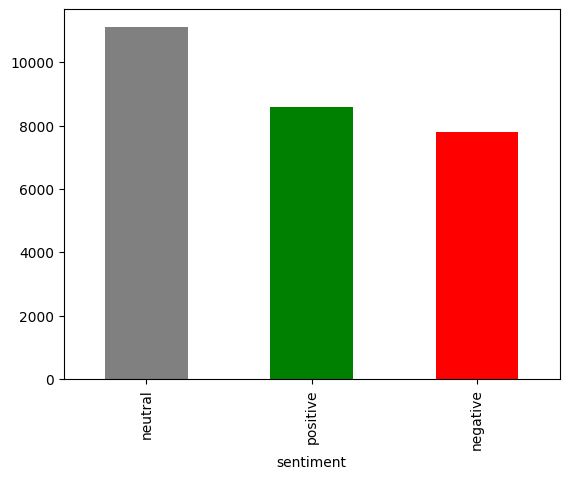

In [ ]:
raw_df['sentiment'].value_counts().plot(kind='bar', color=['gray', 'green', 'red'])

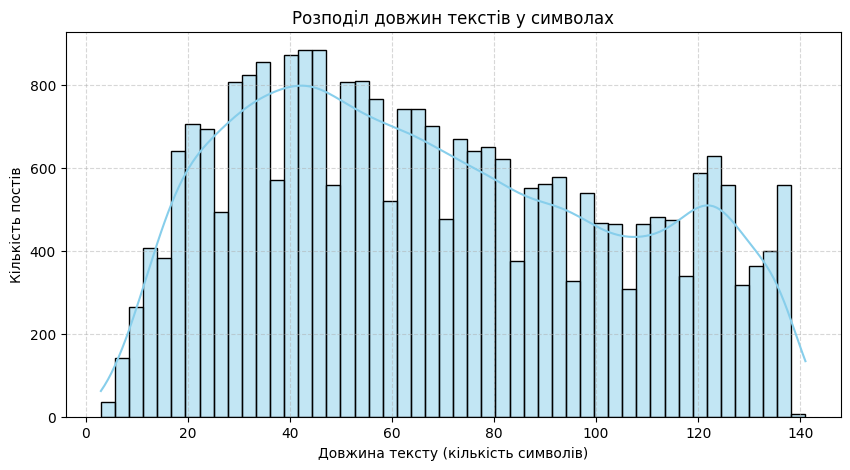

count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

text_len = raw_df['text'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(text_len, bins=50, kde=True, color='skyblue')

plt.title('Розподіл довжин текстів у символах')
plt.xlabel('Довжина тексту (кількість символів)')
plt.ylabel('Кількість постів')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(text_len.describe())

In [ ]:
text_len.median()

64.0

Бачимо, що найбільше постів довжиною 30-50 символів. Найкоротший текст в датасеті містить 3 символи, а найдовший - 141 символ. Розподіл довжин текстів є асиметричним - правоскошеним.  Мода знаходиться в діапазоні 30–50 символів, а середнє значення 68.3 перевищує медіану 64.0, що вказує на наявність правобічного хвоста.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [ ]:
?sklearn.feature_extraction.text.CountVectorizer

Object `sklearn.feature_extraction.text.CountVectorizer` not found.


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
nltk.download('stopwords')
english_stopwords = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
stemmer = SnowballStemmer(language='english')

In [ ]:
def tokenize(text):
    tokens = word_tokenize(text.lower())
    stemmed_tokens = [
        stemmer.stem(word)
        for word in tokens
        if word.lower() not in english_stopwords
    ]
    return stemmed_tokens

In [ ]:
vectorizer = CountVectorizer(lowercase=True,
                             tokenizer=tokenize,
                             max_features = 5000)

In [ ]:
inputs = vectorizer.fit_transform(raw_df['text'])

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
vectorizer.get_feature_names_out()[500:600]

array(['back', 'background', 'backpack', 'backround', 'backup',
       'backyard', 'bacon', 'bacteria', 'bad', 'badg', 'bag', 'bagel',
       'bah', 'bahaha', 'bai', 'bail', 'bailey', 'bak', 'baka', 'bake',
       'bakeri', 'balanc', 'balconi', 'bald', 'bali', 'ball', 'ballerina',
       'baltimor', 'bamboozl', 'ban', 'banana', 'band', 'bandwidth',
       'bang', 'bangin', 'bank', 'banquet', 'bar', 'barack', 'barcelona',
       'bare', 'barn', 'barri', 'bart', 'base', 'basebal', 'basement',
       'bash', 'basic', 'basket', 'basketbal', 'bass', 'bastard', 'bat',
       'bath', 'bathroom', 'batman', 'batteri', 'battl', 'bay', 'bb',
       'bbc', 'bbi', 'bbl', 'bbq', 'bc', 'bday', 'bea', 'bea09', 'beach',
       'bean', 'beani', 'bear', 'beard', 'beast', 'beat', 'beatl',
       'beatwittyparti', 'beauti', 'bebe', 'bebo', 'bec', 'becam',
       'becki', 'becom', 'becuz', 'bed', 'bedroom', 'bedtim', 'bee',
       'beef', 'beer', 'beg', 'begin', 'begun', 'behav', 'behind', 'bein',
       'b

In [ ]:
inputs.shape

(27480, 3000)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [ ]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(inputs, raw_df.sentiment,
                                                                        test_size=0.3, random_state=42)

In [ ]:
logreg = LogisticRegression(max_iter=1000, solver='sag')
logreg.fit(X_train_bow, y_train)

test_preds = logreg.predict(X_test_bow)

f1 = f1_score(y_test, test_preds, average='weighted')
print(f"Weighted F1-score: {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, test_preds))

Weighted F1-score: 0.6904

Classification Report:
              precision    recall  f1-score   support

    negative       0.72      0.59      0.65      2356
     neutral       0.64      0.74      0.68      3343
    positive       0.76      0.72      0.74      2545

    accuracy                           0.69      8244
   macro avg       0.70      0.68      0.69      8244
weighted avg       0.70      0.69      0.69      8244



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
dt = DecisionTreeClassifier(random_state=42, max_depth=30)
dt.fit(X_train_bow, y_train)

dt_test_preds = dt.predict(X_test_bow)

dt_f1 = f1_score(y_test, dt_test_preds, average='weighted')
print(f"Decision Tree Weighted F1-score: {dt_f1:.4f}\n")

print("Classification Report (Decision Tree):")
print(classification_report(y_test, dt_test_preds))

Decision Tree Weighted F1-score: 0.6320

Classification Report (Decision Tree):
              precision    recall  f1-score   support

    negative       0.74      0.39      0.51      2356
     neutral       0.57      0.83      0.67      3343
    positive       0.76      0.63      0.69      2545

    accuracy                           0.64      8244
   macro avg       0.69      0.62      0.62      8244
weighted avg       0.68      0.64      0.63      8244



In [ ]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train_bow, y_train_encoded)

xgb_test_preds_encoded = xgb_model.predict(X_test_bow)

xgb_test_preds = encoder.inverse_transform(xgb_test_preds_encoded)

xgb_f1 = f1_score(y_test, xgb_test_preds, average='weighted')
print(f"XGBoost Weighted F1-score: {xgb_f1:.4f}\n")

print("Classification Report (XGBoost):")
print(classification_report(y_test, xgb_test_preds))

XGBoost Weighted F1-score: 0.6670

Classification Report (XGBoost):
              precision    recall  f1-score   support

    negative       0.76      0.47      0.58      2356
     neutral       0.60      0.81      0.69      3343
    positive       0.77      0.68      0.72      2545

    accuracy                           0.67      8244
   macro avg       0.71      0.65      0.66      8244
weighted avg       0.70      0.67      0.67      8244



Отже за результатами найвищі метрики має логістична регрсія тому надалі будемо використовувати її

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [ ]:
feature_importance = pd.Series(logreg.coef_[2], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance[:10]

,imp
awesom,2.606761
thank,2.396238
cute,2.192229
love,2.130806
amaz,2.032983
great,1.972573
enjoy,1.971327
nice,1.947778
excit,1.841935
happi,1.808974


In [ ]:
feature_importance = pd.Series(logreg.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance[:10]

,imp
sad,2.405674
suck,2.300479
bore,2.181941
sorri,2.120426
hate,2.066899
miss,1.985425
fail,1.906336
sick,1.803796
stupid,1.760525
worst,1.737525


In [ ]:
feature_importance = pd.Series(logreg.coef_[1], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance[:10]

,imp
jst,0.851759
starwarsday,0.794618
parvo,0.778068
wolverin,0.761169
fals,0.756384
thru,0.743799
instal,0.718902
msn,0.692816
logic,0.690706
cop,0.682029


Отже, результати роботи моделі є логічними, для кожного з трьох класів сентименту найбільшу вагу отримали слова, які найточніше передають емоційне забарвлення відповідної категорії.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [ ]:
vectorizer = TfidfVectorizer(lowercase=True,
                             tokenizer = tokenize,
                             max_features = 5000)

tfidf_matrix = vectorizer.fit_transform(raw_df['text'])

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    tfidf_matrix,
    raw_df['sentiment'],
    test_size=0.3,
    random_state=42
)

In [ ]:
logreg_tf = LogisticRegression(max_iter=1000, solver='sag')
logreg_tf.fit(X_train_tf, y_train_tf)

tf_preds = logreg_tf.predict(X_test_tf)
f1_tf = f1_score(y_test_tf, tf_preds, average='weighted')

print(f"TF-IDF Weighted F1-score: {f1_tf:.4f}\n")
print("Classification Report (TF-IDF):")
print(classification_report(y_test_tf, tf_preds))

TF-IDF Weighted F1-score: 0.6856

Classification Report (TF-IDF):
              precision    recall  f1-score   support

    negative       0.72      0.57      0.64      2356
     neutral       0.63      0.76      0.69      3343
    positive       0.77      0.70      0.73      2545

    accuracy                           0.69      8244
   macro avg       0.70      0.68      0.68      8244
weighted avg       0.70      0.69      0.69      8244



In [ ]:
feature_importance = pd.Series(logreg_tf.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance[:15]

,imp
miss,5.423965
sad,5.263317
suck,4.579528
sorri,4.490218
hate,4.332442
bore,4.034411
fail,3.562064
stupid,3.386468
sick,3.382209
poor,3.279096


За результатами експерименту, метрики якості (F1-score) у моделі з Bag-of-Words виявилися вищими за метрики моделі з TF-IDF. Далі я б використовувала саме Bag-of-Words у неї також логічнішими виглядають токени з найбільшим впливом.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [ ]:
raw_df['prediction'] = logreg.predict(inputs)

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(raw_df['sentiment'], raw_df.prediction)

array([[5445, 1929,  407],
       [1029, 9051, 1037],
       [ 284, 1599, 6699]])

Можемо побачити, що найчастіше модель плутає саме нейтральний клас. Проте,  дуже добре відрізняє позитивний від негативного та навпаки.

In [ ]:
neutral_as_negative = raw_df[(raw_df['sentiment'] == 'neutral') & (raw_df['prediction'] == 'negative')]

print("Приклади нейтральних текстів, які модель назвала негативними:\n")
for idx, text in enumerate(neutral_as_negative['text'].head(10), 1):
    print(f"{idx}. {text}")

Приклади нейтральних текстів, які модель назвала негативними:

1. SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cALLed LoSe f0LloWeRs FridAy... smH
2. RATT ROCKED NASHVILLE TONITE..ONE THING SUCKED, NO ENCORE!  LIKE IN THE 80`S THEY STILL HAVE A FUN SHOW. PEARCY HAS THAT HOTT BAD BOY LOOK
3.  also bored at school, its my third freelesson( freistunde )
4. His snoring is so annoying n it keeps me from sleeping (like right now, lol) but I honestly wud miss it if it eva left  I love him.
5. I hate Fallout 3 it keeps making me jump, I`m also low on health, money, ammo and food  don`t worry I`ll get through it.
6.  I had it! On my itunes, but then I lost all my songs.
7. What`s with the gloomy weather? The sun must be too tired to come out and play  heading to victoria gardens for some impulse buys haha
8. tomorrow valeria`s lunch!!! going to get my hair done but im arraving late   got my cousins babtizm or whatever you spell it
9. _Sanderson What`s with Twatter lately?  Either I can`t get on 

In [ ]:
neutral_as_negative = raw_df[(raw_df['sentiment'] == 'neutral') & (raw_df['prediction'] == 'positive')]

print("Приклади нейтральних текстів, які модель назвала позитивними:\n")
for idx, text in enumerate(neutral_as_negative['text'].head(10), 1):
    print(f"{idx}. {text}")

Приклади нейтральних текстів, які модель назвала позитивними:

1. http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth
2.  Car not happy, big big dent in boot! Hoping theyre not going to write it off, crossing fingers and waiting
3.  she is good! so gor-juz yea i kno i asked her yesterday when we were at tha hospital if she talked to u and she said no
4.  cool i wear black most of the time when i go out
5.  thanks. before the major chop.
6.  Thx
7. I just realized that I can`t forward text msgs with my iPhone.
8. I saw amazing heeels. But they were too big
9.  Looking forward to your gig in Ireland!!!  See ya there!
10. [-O] i wish the birthday massacre would come to australia  i think they said they`re thinking about it tho.. http://tinyurl.com/p6lfch


In [ ]:
neutral_as_negative = raw_df[(raw_df['sentiment'] == 'negative') & (raw_df['prediction'] == 'positive')]

print("Приклади негативних текстів, які модель назвала позитивними:\n")
for idx, text in enumerate(neutral_as_negative['text'].head(10), 1):
    print(f"{idx}. {text}")

Приклади негативних текстів, які модель назвала позитивними:

1. WOW, i AM REALLY MiSSiN THE FAM(iLY) TODAY. BADDD.
2. i realy wanted to go out cause its so nice but everybodys busy
3. missed all the awesome weather, because she was in a movie!
4.  I am lost. Please help me find a good home.
5.  l`m on 3 days too matt. No fun this weekend.
6.  I`m 25 in december that`s not good at all next big birthday is 30  after 21 it flys by for sure
7. this week of mine was not easy!  but finally it`s over! (:
8. playing singstar without my fave duetter
9. gettn ready to take a trip to Jersey my dad`s not doing so good, he needs a new heart~whoeva see`s this please say a prayer for my dad
10. Really wishes he had some spare cash to buy the new Punch Out for Wii


In [ ]:
neutral_as_negative = raw_df[(raw_df['sentiment'] == 'positive') & (raw_df['prediction'] == 'negative')]

print("Приклади позитивних текстів, які модель назвала негативними:\n")
for idx, text in enumerate(neutral_as_negative['text'].head(10), 1):
    print(f"{idx}. {text}")

Приклади позитивних текстів, які модель назвала негативними:

1.  She`s unassuming and unpretentious. She`s just, as. I suppose that`s why she`s so endearing--because we can relate to her
2.  We never miss ICarly - my son has a huge crush on Miranda
3. Feeling smooth like chrome
4. almost died. Laptop screen was set to 100% brightness after I reinstalled Windows Vista. Got a headache now  #insanedefaults
5. can`t school just be done already? it hurts too much... seeing him every day
6.   you`re missing out, bb! i`m such a cereal nut, i think i like every kind available.
7.  Discrimination is not a bad thing. I`ve learned to say no. My children would say I mastered that years ago
8.  .. .great.. you can buy me lunch when i get my 10-15% pay cut next month..
9.  I miss u guys too  I prob won`t b bk til august sumtime... But if I come bk anytime b4 then ill 4 sure let u kno!
10.  Oh no!! I hope it`s not bad


Отже, на прикладах можемо побачити, що тексти нейтрального класу є доволі суперечливими, важко однозначно визначити, чи це дійсно нейтральний, позитивний, чи негативний пост.

Способи покращення якості класифікації:

Використання лематизації — це допоможе зберегти більше сенсу, оскільки, на відміну від стеммінгу, не відбувається грубого обрізання закінчень, а слова зводяться до правильної словникової форми.

Використання N-грам  — розширення словника не лише окремими словами, а й словосполученнями. Це допоможе уникнути помилок, коли модель класифікує негативне речення як позитивне, адже у наведених прикладах часто зустрічаються  слова із запереченням (наприклад, not good, no fun), які втрачають зміст при розбитті на окремі слова.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model